# Gradient Variance across 5 Initialization Strategies

Exact (analytic, `shots=None`) gradient variance of IQP circuits for three
connectivity ansaetze (single / circular / full) across three Hamiltonians
(Ising / MaxCut / Partition) and **five** parameter initializations:

| key | init | distribution |
|-----|------|--------------|
| `normal`  | Gaussian        | N(0, 1) |
| `uniform` | Uniform         | U(-pi, pi) |
| `pi4`     | Near-pi/4       | U(pi/4 - eps, pi/4 + eps), eps = 0.05 |
| `he`      | He (Kaiming)    | N(0, 2/n)  (convention A: fan = n_qubits) |
| `glorot`  | Glorot (Xavier) | N(0, 1/n)  (convention A: fan = n_qubits) |

Metric = mean over parameters of Var over `n_trials` random initializations.
Stored **raw**; each subplot is scaled by its own max at plot time.

In [1]:
import pennylane as qp
from pennylane import numpy as qnp
import numpy as np
import json
import matplotlib.pyplot as plt

from IQP_circuit_pennylane import *
from MaxCut import *
from Partition import *

## Patch `ising_obs` into the module
`ising_obs` is not shipped in `IQP_circuit`, so define it and inject it into `IQP_circuit_pennylane` (same as the original notebook).

In [2]:
def ising_obs(n_qubits: int, corr: int = 2) -> np.ndarray:
    observables = []
    for i in range(n_qubits):
        observable = [0] * n_qubits
        observable[i] = 1
        observables.append(observable)
    if corr == 2:
        for i in range(n_qubits):
            for j in range(i + 1, n_qubits):
                observable = [0] * n_qubits
                observable[i] = 1
                observable[j] = 1
                observables.append(observable)
    return np.array(observables, dtype=int)

import IQP_circuit_pennylane
IQP_circuit_pennylane.ising_obs = ising_obs

## Samplers — all five imported from the module
`IQP_circuit_pennylane` now ships all five initializations with a uniform
`(mode_circuit, n_qubits)` signature: `prepare_params_normal`,
`prepare_params_uniform`, `prepare_params_pi4`, `prepare_params_he`,
`prepare_params_glorot`. No notebook-local definitions are needed.

## Gradient variance estimator (exact / analytic)

In [3]:
def gradient_variance_v2(cost, H, mode_circuit, n_qubits,
                         sampler, n_trials=100, print_screen=False):
    grad_fn = qp.grad(cost)
    all_grads = []
    for k in range(n_trials):
        single_params, pair_params = sampler(mode_circuit, n_qubits)
        grad = grad_fn(single_params, pair_params, H, mode_circuit)
        all_grads.append(np.concatenate([grad[0], grad[1]], axis=0))
        if print_screen:
            print(k, 'Done')
    all_grads = np.array(all_grads)
    return float(np.mean(np.var(all_grads, axis=0)))

## Load benchmark Hamiltonian instances

In [4]:
with open("ising.json", "r") as f:
    dataset_ising = {int(k): v for k, v in json.load(f).items()}
with open("maxcut.json", "r") as f:
    dataset_maxcut = {int(k): v for k, v in json.load(f).items()}
with open("partition.json", "r") as f:
    dataset_partition = {int(k): v for k, v in json.load(f).items()}

dataset = {'ising': dataset_ising, 'maxcut': dataset_maxcut, 'partition': dataset_partition}
print("Dataset loaded successfully")

Dataset loaded successfully


## Compute gradient variance for all 5 initializations
Stores **raw** variance (scaling done at plot time).

In [5]:
samplers = {
    'normal':  prepare_params_normal,
    'uniform': prepare_params_uniform,
    'pi4':     prepare_params_pi4,      # U(pi/4 - eps, pi/4 + eps), eps = 0.05
    'he':      prepare_params_he,       # N(0, 2/n) (convention A: fan = n_qubits)
    'glorot':  prepare_params_glorot,   # N(0, 1/n) (convention A: fan = n_qubits)
}

mode_hamiltonians = ['ising', 'maxcut', 'partition']
mode_circuits     = ['single', 'circular', 'full']
qubits            = [3, 6, 9, 12, 15, 18]
n_problem         = 10
n_trials          = 100

all_results = {}

for init_name, sampler in samplers.items():
    print(f"\n{'='*40}\nInit: {init_name}")
    results = {}
    for mode_ham in mode_hamiltonians:
        print(f"  === {mode_ham} ===")
        results[mode_ham] = {}
        for mode_circuit in mode_circuits:
            print(f"    {mode_circuit}")
            results[mode_ham][mode_circuit] = {}
            for n_qubits in qubits:
                print(f"      n={n_qubits}", end=" ... ", flush=True)
                grad_vars = []
                for problem_id in range(n_problem):
                    ops, coeffs = hamiltonian_data(
                        dataset[mode_ham][n_qubits][problem_id], n_qubits, mode_ham)
                    H = binary_ops_to_hamiltonian(ops, coeffs)
                    variance = gradient_variance_v2(
                        cost, H, mode_circuit, n_qubits,
                        sampler=sampler, n_trials=n_trials, print_screen=False)
                    grad_vars.append(variance)
                results[mode_ham][mode_circuit][n_qubits] = grad_vars
                print(f"mean={np.mean(grad_vars):.2e}")
    all_results[init_name] = results

with open("gv_5inits.json", "w") as f:
    json.dump(all_results, f, indent=4)
print("\nSaved to gv_5inits.json")


Init: normal
  === ising ===
    single
      n=3 ... mean=5.53e-01
      n=6 ... mean=1.98e+00
      n=9 ... mean=4.38e+00
      n=12 ... mean=6.35e+00
      n=15 ... mean=1.06e+01
      n=18 ... mean=1.41e+01
    circular
      n=3 ... mean=2.30e-01
      n=6 ... mean=4.66e-01
      n=9 ... mean=8.05e-01
      n=12 ... mean=1.00e+00
      n=15 ... mean=1.51e+00
      n=18 ... mean=1.80e+00
    full
      n=3 ... mean=2.33e-01
      n=6 ... mean=6.93e-02
      n=9 ... mean=1.37e-02
      n=12 ... mean=2.18e-03
      n=15 ... mean=4.15e-04
      n=18 ... mean=6.60e-05
  === maxcut ===
    single
      n=3 ... mean=5.79e+00
      n=6 ... mean=1.42e+01
      n=9 ... mean=1.61e+01
      n=12 ... mean=1.52e+01
      n=15 ... mean=1.71e+01
      n=18 ... mean=1.58e+01
    circular
      n=3 ... mean=2.29e+00
      n=6 ... mean=2.71e+00
      n=9 ... mean=2.48e+00
      n=12 ... mean=2.36e+00
      n=15 ... mean=2.50e+00
      n=18 ... mean=2.16e+00
    full
      n=3 ... mean=2.34e+00
    

## Plot: 3 Hamiltonians x 5 initializations
Each subplot scaled by its own max (per-subplot normalization).

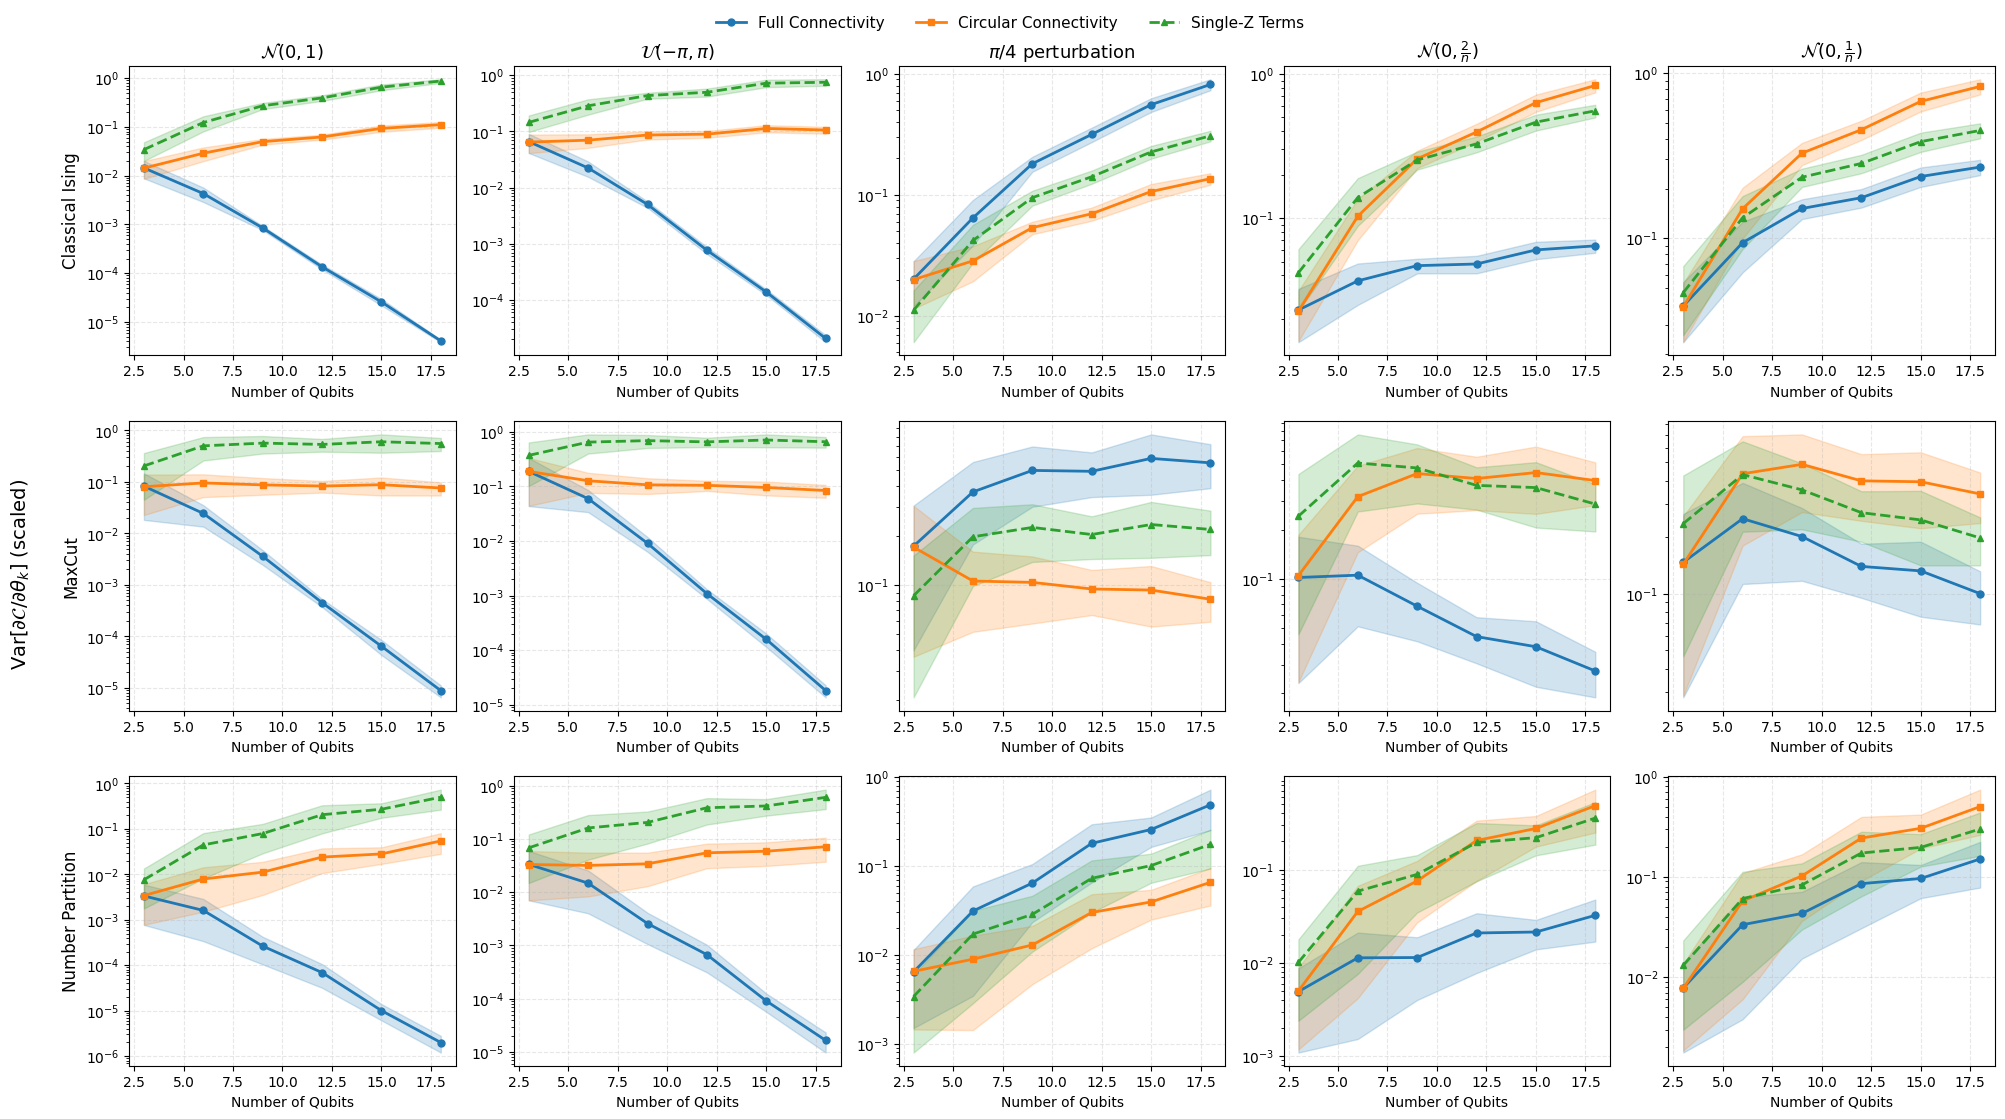

In [4]:
import matplotlib.pyplot as plt
import json
import numpy as np

with open("gv_5inits.json", "r") as f:
    all_results = json.load(f)

qubits = [3, 6, 9, 12, 15, 18]

ham_names = {'ising': 'Classical Ising', 'maxcut': 'MaxCut', 'partition': 'Number Partition'}
styles = {'full': ('o-', '#1f77b4'), 'circular': ('s-', '#ff7f0e'), 'single': ('^--', '#2ca02c')}
labels = {'full': 'Full Connectivity', 'circular': 'Circular Connectivity', 'single': 'Single-Z Terms'}

init_cols  = ['normal', 'uniform', 'pi4', 'he', 'glorot']
col_titles = {
    'normal':  r'$\mathcal{N}(0, 1)$',
    'uniform': r'$\mathcal{U}(-\pi, \pi)$',
    'pi4':     r'$\pi/4$ perturbation',
    'he':      r'$\mathcal{N}(0, \frac{2}{n})$',
    'glorot':  r'$\mathcal{N}(0, \frac{1}{n})$',
}

fig, axes = plt.subplots(3, 5, figsize=(20, 11))

for row, mode_ham in enumerate(['ising', 'maxcut', 'partition']):
    for col, init_name in enumerate(init_cols):
        ax  = axes[row][col]
        res = all_results[init_name][mode_ham]

        # per-subplot scale = max over all circuits & qubits in this panel
        scale = max(v for mc in ['full', 'circular', 'single']
                      for n in qubits for v in res[mc][str(n)])

        for mode_circuit in ['full', 'circular', 'single']:
            means = np.array([np.mean(res[mode_circuit][str(n)]) for n in qubits]) / scale
            stds  = np.array([np.std(res[mode_circuit][str(n)])  for n in qubits]) / scale
            fmt, color = styles[mode_circuit]
            ax.plot(qubits, means, fmt, color=color, label=labels[mode_circuit],
                    linewidth=2, markersize=5)
            ax.fill_between(qubits, means - stds, means + stds, color=color, alpha=0.2)

        ax.set_yscale('log')
        ax.grid(True, alpha=0.3, linestyle='--')
        ax.set_xlabel('Number of Qubits')
        if col == 0:
            ax.set_ylabel(ham_names[mode_ham], fontsize=12)
        if row == 0:
            ax.set_title(col_titles[init_name], fontsize=13)

handles, labels_ = axes[0][0].get_legend_handles_labels()
fig.legend(handles, labels_, loc='upper center', ncol=3,
           bbox_to_anchor=(0.5, 1.02), frameon=False, fontsize=11)
fig.supylabel(r'$\mathrm{Var}\left[\partial \mathcal{C}/\partial \theta_k\right]$ (scaled)', fontsize=14, x=0.0)
plt.tight_layout()
plt.savefig("GV_5_initializations.pdf", dpi=300, bbox_inches='tight')
plt.show()